1. 사용자의 (자소서 내용, 지원 직무) 받기 ex. (~블라블라~, 마케팅) O
2. 사용자의 자소서 내용을 토큰함 -> 키워드화 O
3. 마케팅 직무중 모든기업 자소서 키워드와 사용자 자소서 키워드의 유사도 비교 O
    (직무별 모든 기업의 자소서 토큰화 미리해서 파일로 저장해놔야함) O
4. max때려서 가장 높은 유사도를 보이는 기업의 워드클라우드 띄워주기 O
    <br>당신은 삼성의 인재상이군요! O
5. 가장 높은 유사도를 보이는 기업의 자소서 TOP 5 보여주기(직무일치) O
      <br>시간이 된다면 피드백도 함께 추출?... O
      아니면 링크로 돌려주기?웹사이트 띄워주기?..

+ 감성분석이 된다면 가장 비슷한 자소서의 평가로 점수 매겨주기

In [1]:
import pandas as pd
import requests
import re
from tqdm import tnrange
from tqdm import tqdm
import nltk
from nltk.corpus import stopwords
import pickle as pickle
from konlpy.tag import Twitter
from collections import Counter
import konlpy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from PIL import Image 
from wordcloud import WordCloud, ImageColorGenerator # Image 로부터 Color 를 생성(Generate)해내는 객체입니다.
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from IPython.display import set_matplotlib_formats
%matplotlib inline
import pickle as pickle
from matplotlib import font_manager, rc

In [2]:
content_list = pd.read_pickle("content_list.pkl") # 11 개 기업 자소서 내용
counter_token = pd.read_pickle("counter_2.pkl") # 11개 기업의 자소서 내용을 불처리하고 토큰화한것 딕트
essay_df = pd.read_pickle("essay_df_2.pkl") #대분류 소분류도 긁어온 크롤링 전체 자료
new_del_word = pd.read_pickle("new_del_word.pkl") # set 불용어 추가한 것들 기업이름은 현대만 들어가있음
position_counter_list = pd.read_pickle("position_counter_list.pkl") # 14개 대분류 직무별 자소서 내용 불처리하고 토근화한것
sort_counter_list = pd.read_pickle("sorted_counter_2.pkl") #counter_2 정렬 튜플형식 11개 기업
stopwords = pd.read_json('stopwords-ko.json', encoding = "UTF-8")
my_del_word = pd.read_pickle('my_del_word.pkl') #재실행용
test_df = pd.read_pickle('position_essay_n_nan.pkl') #넌 값 아닌 직무기업정렬 pos작업 안한것
pos_essay_df = pd.read_pickle('pos_essay_df.pkl') #position_essay_n_nan에서 자소서 pos작업하고 str로 각자 묶은것
company_code_dict = pd.read_pickle("company_code_dict.pkl")

### 사용자 정보 입력받기 & 사용자 지원직무와 매치하는 자기소개서 데이터프레임 만들기

In [4]:
position_list = list(pos_essay_df["position_broad"].unique()) #직무목록을 만들어주기(대분류)
show_position_str = '' #빈 str생성

for x in range(len(position_list)):
    show_position_str += ('[' + str(x + 1) + '] ' + position_list[x] + '\n') #숫자와 직무이름 합치기

print("[직무 목록]")
print(show_position_str) # 숫자와 직무이름 합친것을 한줄씩 출력

while True: 
    user_position_num = int(input("직무 목록을 확인하고 지원할 직무의 번호를 입력해주세요.\n")) #int로 안바꿔주면 무한루프에 갇힙니다.
    if (user_position_num - 1) not in range(len(position_list)): #직무번호가 1부터 시작해서 -1을 해줌
        print("잘못 입력하셨습니다. 다시 입력해주세요.")
        continue
    else:
        break
        
user_cv = input("본인의 자기소개서를 입력해주세요.\n")


[직무 목록]
[1] IT·인터넷
[2] 건설
[3] 경영·사무
[4] 교육
[5] 디자인
[6] 마케팅·광고·홍보
[7] 무역·유통
[8] 미디어
[9] 생산·제조
[10] 서비스
[11] 연구개발·설계
[12] 영업·고객상담
[13] 전문·특수직

직무 목록을 확인하고 지원할 직무의 번호를 입력해주세요.
1
본인의 자기소개서를 입력해주세요.
LG CNS가 최근 IT서비스 업계 최초로 IOT 국제표준 인증 ‘oneM2M' 인증과 동시에 'CoAP 프로토콜’ 연동 호환성 인증을 획득했다는 소식을 접했습니다. 학부 졸업프로젝트를 통해서 'CoAP‘ 기술을 처음 접하게 되었고 IOT에 관심을 가지게 되어 비콘 기술을 이용하여 졸업프로젝트를 개발하였습니다. IOT 기술은 미래 산업의 중심으로서 가장 투자해야할 사업이라고 생각하며, 인간의 삶을 더 풍족하게 만들어 줄 수 있다고 생각합니다.저의 꿈은 IOT를 통해 적은 노동력을 사용하여 사람이 더 편리해질 수 있는 기술을 개발하는 것입니다. LG CNS에서는 서버 시설 청소 스마트 로봇, 스마트홈 구현을 위한 셋톱박스 개발 등 IOT 기술 개발을 위해 많은 투자를 하고 있습니다. 사람을 위한 서비스를 개발하는 것에서 저와 같은 길을 가고 있다고 생각합니다. 고객 가치를 최우선적으로 생각하는 LG CNS에서 저의 LG WAY를 구축하고 싶습니다 CEST 임베디드 연구소에서 주체한 프로젝트 공모전에 친구들과 팀을 이루어 참여한 일이 있었습니다. 주제는 ‘BLE 비콘을 이용한 스마트자전거 군집주행’으로 전기자전거의 현재 위치 좌표와 자전거 간의 거리를 GPS와 비콘의 보정 알고리즘을 통해 측정한 후 군집상에서 자전거의 위치를 휴대폰 어플리케이션에 표시하는 것 입니다. 자전거 간의 거리는 기준 거리에 비해 가까울 시 전기자전거의 속도를 줄이고 거리가 멀어질 때는 속도를 높이는 속도 자동제어 기능을 아두이노에서 전기자전거 신호 제어 알고리즘을 통해 구현하였습니다. 프로젝트의 완성 후 성과를 인정받아 3학년 겨울방학에 연구소에서

In [123]:
# # 테스트용
# user_cv = """LG CNS가 최근 IT서비스 업계 최초로 IOT 국제표준 인증 ‘oneM2M' 인증과 동시에 'CoAP 프로토콜’ 연동 호환성 인증을 획득했다는 소식을 접했습니다. 학부 졸업프로젝트를 통해서 'CoAP‘ 기술을 처음 접하게 되었고 IOT에 관심을 가지게 되어 비콘 기술을 이용하여 졸업프로젝트를 개발하였습니다. IOT 기술은 미래 산업의 중심으로서 가장 투자해야할 사업이라고 생각하며, 인간의 삶을 더 풍족하게 만들어 줄 수 있다고 생각합니다.저의 꿈은 IOT를 통해 적은 노동력을 사용하여 사람이 더 편리해질 수 있는 기술을 개발하는 것입니다. LG CNS에서는 서버 시설 청소 스마트 로봇, 스마트홈 구현을 위한 셋톱박스 개발 등 IOT 기술 개발을 위해 많은 투자를 하고 있습니다. 사람을 위한 서비스를 개발하는 것에서 저와 같은 길을 가고 있다고 생각합니다. 고객 가치를 최우선적으로 생각하는 LG CNS에서 저의 LG WAY를 구축하고 싶습니다
# CEST 임베디드 연구소에서 주체한 프로젝트 공모전에 친구들과 팀을 이루어 참여한 일이 있었습니다. 주제는 ‘BLE 비콘을 이용한 스마트자전거 군집주행’으로 전기자전거의 현재 위치 좌표와 자전거 간의 거리를 GPS와 비콘의 보정 알고리즘을 통해 측정한 후 군집상에서 자전거의 위치를 휴대폰 어플리케이션에 표시하는 것 입니다. 자전거 간의 거리는 기준 거리에 비해 가까울 시 전기자전거의 속도를 줄이고 거리가 멀어질 때는 속도를 높이는 속도 자동제어 기능을 아두이노에서 전기자전거 신호 제어 알고리즘을 통해 구현하였습니다.
# 프로젝트의 완성 후 성과를 인정받아 3학년 겨울방학에 연구소에서 인턴을 하였습니다. 연구소에서는 지그비 기반 전자가격표시기(ESL) 사업을 중점으로 진행하여 대형마트와 백화점에 납품을 하고 있었습니다. ESL 프로그램의 서버DB 업데이트 및 버그를 테스트하는 업무를 하였으며 그 과정에서 ESL 프로그램의 구조에 대해 자세히 알 수 있었습니다.
# LG CNS에서 새만금간척지에 2022년까지 막대한 투자를 하여 스마트팜을 완공한다는 계획을 알게 되었습니다.
# 농업이란 우리의 삶에서 뗄 수 없는 존재 입니다. 하지만 농업에 종사하는 인구는 점점 감소하고 있으며 노동력이 점점 줄어들고 있기에 스마트팜 기술이 꼭 필요하다고 생각합니다. 저는 LG CNS의 ITP 직무를 맡아 완벽한 스마트팜 시스템을 구축하는데 기여하겠습니다. 나아가 10년 뒤에는 새만금간척지 스마트팜 시스템을 안정화하고 더 확장해서 네덜란드의 ‘애그리포트 A7' 지역과 같은 방대한 스마트팜을 구축하기 위해 노력하겠습니다.
# 그러기 위해선 IOT 기술을 활용한 자동온도조절 시스템과 수분공급 시스템, 재배 정도 분석 시스템 등 스마트팜 자동화에 필요한 기술을 익히겠습니다. 그리고 고객만족도 부분에 아직 미흡한 기술인 수확 및 포장 자동화 기술을 보완하여 스마트팜 분야에서 앞서가는 일등 LG를 만들어 가겠습니다""" # 사용자 자소서내용

In [5]:
user_position = position_list[user_position_num - 1] # 사용자 지원 직무 #인덱스는 0부터인데 직무목록이 1부터로 보여줘서 -1
target_df = pos_essay_df[pos_essay_df["position_broad"] == user_position]  #사용자 직무와 일치하는 자소서 데이터프레임

### 사용자 자기소개서 형태소 및 불용어 처리하기

In [6]:
my_del_word = list(my_del_word) #set타입을 list로 불용어 따로 추가한 모음집
stopwords = list(stopwords) #set타입을 list로
common_del_list = ['되어다','때문','그리고','좋다','자다','없다','같다','싶다','보다', '하다', '있다', '되다', '이다', '돼다', '않다', '그렇다', '아니다', '이렇다', '그렇다', '어떻다']
del_list = stopwords + common_del_list + my_del_word
counter_list = []

def user_cv_pos(user_cv): #형태소 & 불처리하여 다시 str로 반환해주는 함수
    
    
    twitter = Twitter()
    raw_pos_tagged = twitter.pos(user_cv, norm=True, stem=True) 
 
    word_cleaned = []
    
    for word, tag in raw_pos_tagged: 
        if not tag in ["Josa", "Eomi", "Punctuation", "Foreign"]: 
            if (len(word) != 1) & (word not in del_list): 
                word_cleaned.append(word)
                
    list_to_str = ' '.join(word_cleaned) # list를 다시 하나의 str로 붙여줌
    return list_to_str

In [7]:
clean_user_cv = user_cv_pos(user_cv) #사용자의 자기소개서 형태소%불처리 후 str로 돌려받기

C:\Users\kimhy\Anaconda3\lib\site-packages\konlpy\tag\_okt.py:16: UserWarning: "Twitter" has changed to "Okt" since KoNLPy v0.4.5.
  warn('"Twitter" has changed to "Okt" since KoNLPy v0.4.5.')


### TF-IDF & 인덱스 번호(고유번호 활용) & max로 비슷한 기업이 뭔지 알려주기

In [19]:
def tf_idf(user_position, clean_user_cv, target_content):
    corpus = [user_cv, target_content]
    vectorizer = TfidfVectorizer()
    X = vectorizer.fit_transform(corpus).todense()
    cosine_similar = cosine_similarity(X[0], X[1])
    print(cosine_similarity(X[0], X[1]))
    return cosine_similar

In [20]:
for x in range(len(target_df)): #사용자의 직무와 일치하는 모든 자기소개서 tf-idf 후 코사인 유사도 측정
    target_content = target_df["content"].values[x] #사용자의 직무와 일치하는 자기소개서
    if x == 0: #인덱스가 0일때 max의 비교대상이 없기때문에 따로 설정
        max_cosine_score = tf_idf(user_position, clean_user_cv, target_content) # tf-idf계산
        max_idx = int(target_df["content"][x:x+1].index.values) #가장 유사한 자기소개서의 인덱스 저장
    else :
        new_cosine_score = tf_idf(user_position, clean_user_cv, target_content)
        if new_cosine_score > max_cosine_score : #현재와 전에 돌린 자기소개서 중에 어떤 것이 더 유사한가
            max_cosine_score = new_cosine_score # 현재가 더 유사하면 현재를 max로 지정
            max_idx = int(target_df["content"][x:x+1].index.values) # 현재가 더 유사하면 현재idx를 max로 지정
            
max_cosine_score = round(float(max_cosine_score),9) #코사인 유사도 소수점 9번째까지 반올림

print(f'제일 유사한 자소서의 인덱스 번호는{max_idx} 이며, 코사인 유사도는 {max_cosine_score}입니다.')

[[0.02818291]]
[[0.03046025]]
[[0.02523803]]
[[0.01600035]]
[[0.02020033]]
[[0.02090746]]
[[0.04185741]]
[[0.05387734]]
[[0.03916505]]
[[0.05294804]]
[[0.03428939]]
[[0.07043554]]
[[0.04211932]]
[[0.01560814]]
[[0.03531798]]
[[0.08117]]
[[0.02368382]]
[[0.05611294]]
[[0.04029661]]
[[0.02377666]]
[[0.0466411]]
[[0.05159607]]
[[0.03620049]]
[[0.01792562]]
[[0.01688983]]
[[0.02692661]]
[[0.04901959]]
[[0.07960092]]
[[0.04834797]]
[[0.0469567]]
[[0.04190968]]
[[0.04323397]]
[[0.04522891]]
[[0.05777056]]
[[0.05852748]]
[[0.08157428]]
[[0.05395542]]
[[0.03081391]]
[[0.02710803]]
[[0.03327348]]
[[0.0376969]]
[[0.02894485]]
[[0.02971063]]
[[0.02224813]]
[[0.05030479]]
[[0.03471934]]
[[0.05074825]]
[[0.03758856]]
[[0.04923822]]
[[0.03669965]]
[[0.04406159]]
[[0.06305217]]
[[0.029478]]
[[0.06147075]]
[[0.03206612]]
[[0.05002604]]
[[0.02829619]]
[[0.04694912]]
[[0.01695923]]
[[0.06497633]]
[[0.02645694]]
[[0.0281949]]
[[0.0519948]]
[[0.05639536]]
[[0.02044665]]
[[0.02383177]]
[[0.02678907]]
[[0.0

In [10]:
similar_df = pos_essay_df.iloc[[max_idx]] # 유사한 자소서 데이터프레임 검색
similar_company_id = similar_df["company_id"].values[0] # 유사한 자소서의 기업id 검색

## 워드클라우드

In [11]:
def make_word_cloud(image_file, save_name, word_dic): #워드 클라우드를 보여주는 함수
    
    company_coloring = np.array(Image.open(image_file))
    image_colors = ImageColorGenerator(company_coloring)
    
    word_cloud = WordCloud(font_path="HSBombaram3.0_Regular.ttf",
                       width=1000, height=1000,  
                       max_words=100,
                       min_font_size = 5,
                       mask=company_coloring, 
                       contour_color='white',
                       contour_width=0.001,
                       background_color='white', 
                       max_font_size=50, 
                      ).generate_from_frequencies(word_dic)
    
    plt.figure(figsize=(10,10))
    set_matplotlib_formats('retina')
    plt.imshow(word_cloud.recolor(color_func=image_colors), interpolation='bilinear')
    plt.axis("off")
    plt.tight_layout(pad=0)
    plt.savefig(save_name)
    
#     plt.title(image_file)
#     font_name = font_manager.FontProperties(fname="/Users/haeunkang/Library/Fonts/malgun.ttf").get_name()
#     rc('font', family="AppleGothic")
    
    plt.show()

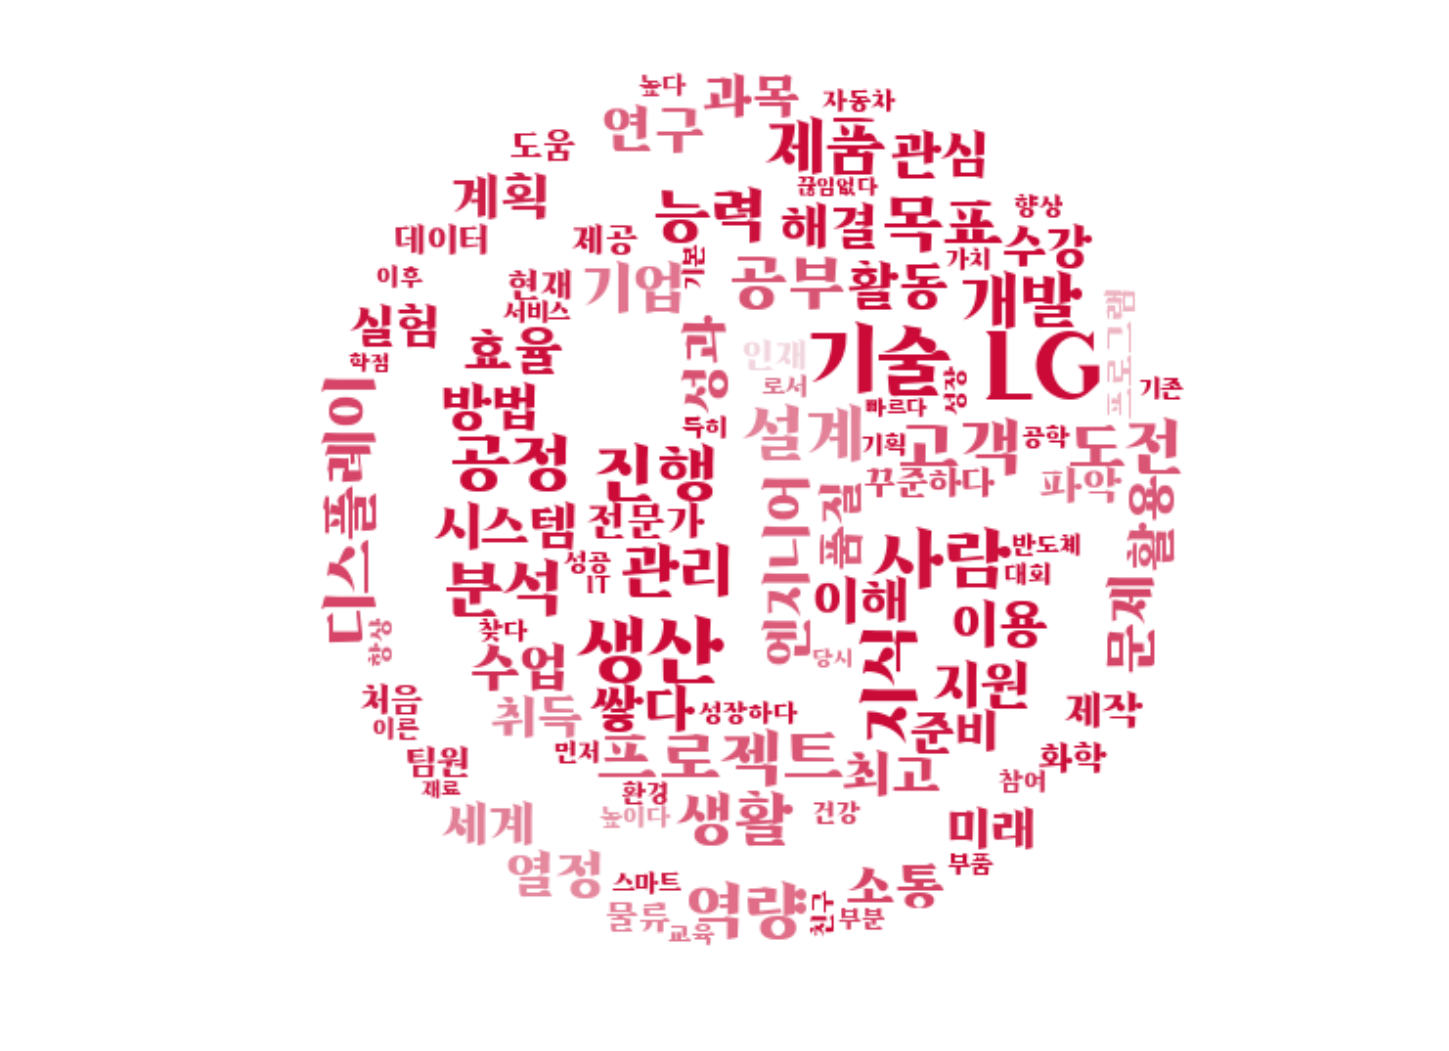

당신은 LG의 인재상에 가깝습니다!
당신의 자기소개서 점수는 5점 만점에 5.0점 입니다!


In [14]:
company = company_code_dict[similar_company_id] #가장 유사한 자기소개서의 기업(대표)의 이름
make_word_cloud(f'{company}.png', f'{company}_wc', counter_token[similar_company_id]) # 가장 유사한 기업(대표)의 워드클라우드
user_score = test_df["score"][max_idx] # 가장 유사한 자기소개서의 점수로 할당
print(f'당신은 {company}의 인재상에 가깝습니다!')
print(f'당신의 자기소개서 점수는 5점 만점에 {user_score}점 입니다!')

In [15]:
#지원한 직무와 일치하면서 가장 유사한 기업의 자기소개서 데이터프레임 만들기
temp_company_df = test_df[(test_df["company_id"] == similar_company_id) & (test_df["position_broad"] == user_position)]
similar_company_top = temp_company_df.sort_values(["score"], ascending = False).head(5) #가장 높은 점수로 정렬
similar_company_top.reset_index(inplace = True) # for문을 인덱스로 접근하기위해 인덱스 리셋

In [21]:
for idx in similar_company_top.index: # top5 자기소개서 보여주기
    top_score = similar_company_top["score"][idx] # 상위 자기소개서가 받은 점수
    top_company_name = similar_company_top["company"][idx] # 상위 자기소개서의 합격 기업(계열사이름)
    if idx == 0:
        print("\n당신과 가까운 인재상을 가진 기업의 자기소개서 상위 5개 입니다.\n\n")
        print(f'[{idx + 1}위]\n')
        print(f'점수 : 5점 만점에 {top_score}점')
        print(f'합격 회사 : {company}그룹의 {top_company_name}\n')
        print(similar_company_top["content"][idx] + "\n\n\n") #자기소개서 내용
    else:
        print(f'[{idx + 1}위]\n')
        print(f'점수 : 5점 만점에 {top_score}점')
        print(f'합격 기업 {company}그룹의 {top_company_name}\n')
        print(similar_company_top["content"][idx] + "\n\n\n") #자기소개서 내용
        print()


당신과 가까운 인재상을 가진 기업의 자기소개서 상위 5개 입니다.


[1위]

점수 : 5점 만점에 5.0점
합격 회사 : LG그룹의 LG CNS

"코딩을 이용해 키운 통계적 역량으로 혁신에 기여하고 싶습니다" 새내기 시절 놀기 좋아하던 저의 관심을 처음으로 끈 전공 수업은 컴퓨터자료처리 수업이었습니다. R과 SAS 등 통계 프로그램을 이용하니 복잡한 계산에 정신이 팔리지 않고 통계적 원리를 더 파고들 수 있었습니다. 깨달은 원리를 코딩으로 실현시키는 것에 재미를 느껴 해당 수업에서 일 등을 할 정도로 흥미와 열정을 가지고 공부했습니다. 그 수업을 계기로 자신감을 얻어 혼자서 파이썬과 VBA를 추가로 공부하고, R 마크다운을 이용하는 법이나 정규표현식 등 다양하게 코드를 구현하는 방법을 배워 통계분석과 코딩 역량을 꾸준히 발전시켰습니다.  이런 저에게 LG CNS는 제 역량을 발휘하고 관련 기술을 더 키울 수 있는 완벽한 회사입니다. 본사에서 인턴 생활을 한 과 동기를 통해 회사를 알게 되었는데, 통계학도로서 실제 데이터를 이용해 아이디어를 내고, 분석해 그 결과가 쓸모 있게 쓰이게 되는 보람을 느끼며 일할 수 있는 곳이라고 생각했습니다. 교통카드와 카카오페이와 같이 생활에 가장 밀접하게 쓰고 있는 기술을 직접 개발하며 혁신적인 아이디어를 실현시키는데 가장 핵심적인 역할을 하는 LG CNS에서 대량의 데이터를 통해 의미 있는 인사이트를 얻고 혁신을 만들어 가는데 참여하고 싶습니다. 특히 본사가 추진하는 스마트팩토리와 스마트 물류 사업에 관련해 일하고 싶습니다. 이 사업은 디지털 플랫폼을 통해 산업들을 연결해 4차 산업 시대를 이끌 사업이라고 생각합니다. 본사가 보유하고 있는 접근하기 힘든 다양한 산업군의 회사들의 데이터를 이용해 다양한 산업에 도움을 주는 유의미한 분석을 할 것입니다.SW Boot Camp에 참가해 LG CNS의 전문가들 하, JAVA나 C 등 언어를 심도 있게 배워 실제 빅데이터를 가지고 연습할 기회를 얻고 싶습니다. 입사 후에는 데이터

### Bonus

In [22]:
answer = input("당신과 가장 유사한 자기소개서가 궁금하신가요?\
                \n궁금하다면 yes 궁금하지 않다면 아무 단어나 입력해주세요\n")
if answer == 'yes':
    similar_cv = test_df["content"][max_idx] #사용자와 가장 유사한 자기소개서 내용
    similar_cv_company = test_df["company"][max_idx] # 사용자와 가장 유사한 자기소개서의 합격 기업(계열사이름)
    print("\n\n\n당신과 유사한 자기소개서 입니다.\n\n")
    print(f'점수 : 5점 만점에 {user_score}점')
    print(f'합격 기업 : {company}그룹의 {similar_cv_company}')
    print("\n" + similar_cv)
else :
    print("프로그램을 종료합니다.")

당신과 가장 유사한 자기소개서가 궁금하신가요?                
궁금하다면 yes 궁금하지 않다면 no를 입력해주세요
yes



당신과 유사한 자기소개서 입니다.


점수 : 5점 만점에 5.0점
합격 기업 : LG그룹의 LG CNS

[미래 기술의 핵심, IOT] LG CNS가 최근 IT서비스 업계 최초로 IOT 국제표준 인증 ‘oneM2M' 인증과 동시에 'CoAP 프로토콜’ 연동 호환성 인증을 획득했다는 소식을 접했습니다. 학부 졸업프로젝트를 통해서 'CoAP‘ 기술을 처음 접하게 되었고 IOT에 관심을 가지게 되어 비콘 기술을 이용하여 졸업프로젝트를 개발하였습니다. IOT 기술은 미래 산업의 중심으로서 가장 투자해야할 사업이라고 생각하며, 인간의 삶을 더 풍족하게 만들어 줄 수 있다고 생각합니다. 저의 꿈은 IOT를 통해 적은 노동력을 사용하여 사람이 더 편리해질 수 있는 기술을 개발하는 것입니다. LG CNS에서는 서버 시설 청소 스마트 로봇, 스마트홈 구현을 위한 셋톱박스 개발 등 IOT 기술 개발을 위해 많은 투자를 하고 있습니다. 사람을 위한 서비스를 개발하는 것에서 저와 같은 길을 가고 있다고 생각합니다. 고객 가치를 최우선적으로 생각하는 LG CNS에서 저의 LG WAY를 구축하고 싶습니다. CEST 임베디드 연구소에서 주체한 프로젝트 공모전에 친구들과 팀을 이루어 참여한 일이 있었습니다. 주제는 ‘BLE 비콘을 이용한 스마트자전거 군집주행’으로 전기자전거의 현재 위치 좌표와 자전거 간의 거리를 GPS와 비콘의 보정 알고리즘을 통해 측정한 후 군집상에서 자전거의 위치를 휴대폰 어플리케이션에 표시하는 것 입니다. 자전거 간의 거리는 기준 거리에 비해 가까울 시 전기자전거의 속도를 줄이고 거리가 멀어질 때는 속도를 높이는 속도 자동제어 기능을 아두이노에서 전기자전거 신호 제어 알고리즘을 통해 구현하였습니다. 프로젝트의 완성 후 성과를 인정받아 3학년 겨울방학에 연구소에서 인턴을 하였습니다. 연구소에서는 지그비 기반 전자가격표시기(ES

In [23]:
answer = input("당신과 가장 유사한 자기소개서의 피드백이 궁금하신가요?\
                \n궁금하다면 yes 궁금하지 않다면 아무 단어나 입력해주세요\n")
if answer == 'yes':
    similar_cv_feedback = test_df["feedback"][max_idx]
    print(f"\n\n\n당신과 유사한 자기소개서의 피드백 입니다. 점수는 {user_score}점 입니다.\n")
    print("\n" + similar_cv_feedback)
else :
    print("프로그램을 종료합니다.")

당신과 가장 유사한 자기소개서의 피드백이 궁금하신가요?                
궁금하다면 yes 궁금하지 않다면 no를 입력해주세요
yes



당신과 유사한 자기소개서의 피드백 입니다. 점수는 5.0점 입니다.


본 자기소개서의 장점은 제시한 내용이 군더더기 없이 깔끔하게 정리되어 있다는 것입니다. 글을 잘 정리하는 장점이 있는 지원자 입니다. 첫 번째 항목인 지원동기를 작성할 때, 회사에 대해 많은 것을 알고 있다는 느낌을 준 점도 좋고 내용을 구체적으로 제시한 점도 좋습니다. 기술직으로 지원하는 자기소개서에 걸맞게 자신이 어떤 활동을 했는지 적극적으로 제시한 점도 좋고, 그 내용도 호감이 갑니다. 마지막 포부항목 역시, 지원하는 회사가 현재 진행하는 사업을 적극적으로 제시한 점, 해외 사례를 제시한 점, 보완점을 제시한 점이 돋보입니다.
